# Task 2 — High-Dimensional Exploratory Data Analysis (EDA)
***

This notebook reads only curated outputs produced by Task 1. It uses PySpark SQL/DataFrames for temporal and spatial analysis, demonstrates the physical impact of an explicit Spark broadcast join, computes a three-month rolling community-area crime-frequency series, and evaluates how **specific weather-event days** relate to crime frequency.

> **Rate terminology.** The supplied socioeconomic dataset contains no community-area population denominator. Therefore the required rolling calculation is reported honestly as a rolling crime frequency, not mislabelled as a population-normalised crime rate. A true crimes-per-100,000 rate requires a compatible population dataset and is identified as a limitation rather than fabricated.


In [1]:
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

import os
from pathlib import Path

# --- Paths ---------------------------------------------------------------
# Resolved relative to the project root (walks up from the notebook's cwd
# until it finds a Data/ folder; override with CHICAGO_PROJECT_ROOT if you
# launch the kernel from elsewhere, e.g. Colab/Databricks).

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Data").is_dir():
            return candidate
    return start

PROJECT_ROOT = Path(
    os.environ.get("CHICAGO_PROJECT_ROOT") or _find_project_root(Path.cwd())
).resolve()

PROCESSED = str(PROJECT_ROOT / "data" / "processed")
REPORT_DIR = str(PROJECT_ROOT / "reports")
SPARK_TMP_DIR = str(PROJECT_ROOT / "spark_tmp")

for _d in (REPORT_DIR, SPARK_TMP_DIR):
    os.makedirs(_d, exist_ok=True)

spark = (
    SparkSession.builder.appName("ChicagoCrime-Task2-EDA")
    # Pin the driver to loopback so Spark's internal Netty RPC server
    # doesn't depend on the machine's hostname resolving (macOS .local
    # mDNS names can stop resolving after a network change/sleep-wake,
    # which otherwise crashes SparkContext init with
    # UnresolvedAddressException before any code even runs).
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.local.dir", SPARK_TMP_DIR)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

crime = spark.read.parquet(PROCESSED + "/crime_clean_flat")
census = spark.read.parquet(PROCESSED + "/census_community_areas")
weather = spark.read.parquet(PROCESSED + "/weather_daily")
crime.createOrReplaceTempView("crime")
census.createOrReplaceTempView("census")
weather.createOrReplaceTempView("weather")
print("crime rows:", crime.count(), " | census rows:", census.count(), " | weather days:", weather.count())

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 20:54:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/27 20:54:15 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


crime rows: 7784664  | census rows: 77  | weather days: 8035


## 1. Temporal analysis (PySpark SQL)

In [2]:
yearly_trend = spark.sql("""
    SELECT crime_year, COUNT(*) AS n_crimes, SUM(CASE WHEN arrest THEN 1 ELSE 0 END) AS n_arrests
    FROM crime
    WHERE crime_year BETWEEN 2001 AND 2022
    GROUP BY crime_year
    ORDER BY crime_year
""")
yearly_trend.show(25)

hourly_profile = spark.sql("""
    SELECT crime_hour, COUNT(*) AS n_crimes
    FROM crime GROUP BY crime_hour ORDER BY crime_hour
""")
hourly_profile.show(24)

dow_profile = spark.sql("""
    SELECT crime_dow, COUNT(*) AS n_crimes
    FROM crime GROUP BY crime_dow ORDER BY crime_dow
""")
dow_profile.show()

+----------+--------+---------+
|crime_year|n_crimes|n_arrests|
+----------+--------+---------+
|      2001|  485878|   141932|
|      2002|  486802|   141563|
|      2003|  475979|   141587|
|      2004|  469421|   144698|
|      2005|  453771|   140921|
|      2006|  448174|   135418|
|      2007|  437084|   131877|
|      2008|  427167|   110013|
|      2009|  392819|   110824|
|      2010|  370496|   100537|
|      2011|  351964|    96284|
|      2012|  336262|    90659|
|      2013|  307468|    86535|
|      2014|  275731|    79627|
|      2015|  264755|    70034|
|      2016|  269786|    53023|
|      2017|  269071|    52642|
|      2018|  268773|    53859|
|      2019|  261245|    56207|
|      2020|  212092|    34084|
|      2021|  208571|    26288|
|      2022|  238215|    27420|
+----------+--------+---------+



+----------+--------+
|crime_hour|n_crimes|
+----------+--------+
|         0|  444272|
|         1|  246808|
|         2|  207893|
|         3|  168561|
|         4|  127941|
|         5|  106840|
|         6|  124613|
|         7|  177870|
|         8|  263432|
|         9|  336467|
|        10|  329969|
|        11|  345202|
|        12|  446899|
|        13|  369553|
|        14|  392468|
|        15|  414378|
|        16|  393014|
|        17|  399856|
|        18|  425556|
|        19|  438502|
|        20|  436963|
|        21|  423861|
|        22|  416908|
|        23|  346838|
+----------+--------+

+---------+--------+
|crime_dow|n_crimes|
+---------+--------+
|        1| 1058672|
|        2| 1100146|
|        3| 1112642|
|        4| 1119819|
|        5| 1108515|
|        6| 1169913|
|        7| 1114957|
+---------+--------+



## 2. Spatial analysis + BROADCAST JOIN (Spark Broadcast variables)

`census` (77 rows) is orders of magnitude smaller than `crime`. Without a
broadcast hint, a join on `community_area` triggers a shuffle of the
large table (`SortMergeJoin`/`ShuffleHashJoin`): every row of the
multi-million-row fact table is repartitioned across the cluster by join
key. With `broadcast()`, Spark instead ships the tiny table's full
contents to every executor's memory once, so each executor can do the
join locally with zero shuffle of the crime table.

In [3]:
print("=== WITHOUT broadcast hint, auto-broadcast DISABLED (forces a shuffle join) ===")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
t0 = time.time()
shuffle_join = crime.join(census, on="community_area", how="left")
shuffle_join.explain(mode="formatted")
n1 = shuffle_join.count()
t_shuffle = time.time() - t0
print(f"Shuffle join count={n1} rows, took {t_shuffle:.2f}s")

print("\n=== WITH explicit broadcast() hint ===")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "10485760")  # restore default (10MB)
t1 = time.time()
broadcast_join = crime.join(F.broadcast(census), on="community_area", how="left")
broadcast_join.explain(mode="formatted")
n2 = broadcast_join.count()
t_broadcast = time.time() - t1
print(f"Broadcast join count={n2} rows, took {t_broadcast:.2f}s "
      f"({(t_shuffle/max(t_broadcast,0.001)):.2f}x vs shuffle join)")

assert n1 == n2, "Row counts must match between join strategies"

broadcast_join.createOrReplaceTempView("crime_enriched")
spatial = spark.sql("""
    SELECT community_area, community_area_name, COUNT(*) AS n_crimes,
           ROUND(AVG(CASE WHEN arrest THEN 1.0 ELSE 0.0 END), 4) AS arrest_rate
    FROM crime_enriched
    WHERE community_area IS NOT NULL
    GROUP BY community_area, community_area_name
    ORDER BY n_crimes DESC
""")
spatial.show(15, truncate=False)

=== WITHOUT broadcast hint, auto-broadcast DISABLED (forces a shuffle join) ===
== Physical Plan ==
AdaptiveSparkPlan (10)
+- Project (9)
   +- SortMergeJoin LeftOuter (8)
      :- Sort (3)
      :  +- Exchange (2)
      :     +- Scan parquet  (1)
      +- Sort (7)
         +- Exchange (6)
            +- Filter (5)
               +- Scan parquet  (4)


(1) Scan parquet 
Output [28]: [id#0L, case_number#1, event_ts#2, crime_date#3, crime_year#4, crime_month#5, crime_day#6, crime_hour#7, crime_dow#8, is_weekend#9, day_part#10, block#11, iucr#12, primary_type#13, description#14, location_description#15, arrest#16, domestic#17, beat#18, district#19, ward#20, community_area#21, fbi_code#22, latitude#23, longitude#24, geo_valid#25, community_area_valid#26, updated_ts#27]
Batched: true
Location: InMemoryFileIndex [file:/Users/damithkayatech.com/Documents/MSc/BD Technologies Assignment/PRAC 1/Chicago_Crime_Analysis_Project/data/processed/crime_clean_flat]
ReadSchema: struct<id:bigint,case_numb

Shuffle join count=7784664 rows, took 1.09s

=== WITH explicit broadcast() hint ===
== Physical Plan ==
AdaptiveSparkPlan (7)
+- Project (6)
   +- BroadcastHashJoin LeftOuter BuildRight (5)
      :- Scan parquet  (1)
      +- BroadcastExchange (4)
         +- Filter (3)
            +- Scan parquet  (2)


(1) Scan parquet 
Output [28]: [id#0L, case_number#1, event_ts#2, crime_date#3, crime_year#4, crime_month#5, crime_day#6, crime_hour#7, crime_dow#8, is_weekend#9, day_part#10, block#11, iucr#12, primary_type#13, description#14, location_description#15, arrest#16, domestic#17, beat#18, district#19, ward#20, community_area#21, fbi_code#22, latitude#23, longitude#24, geo_valid#25, community_area_valid#26, updated_ts#27]
Batched: true
Location: InMemoryFileIndex [file:/Users/damithkayatech.com/Documents/MSc/BD Technologies Assignment/PRAC 1/Chicago_Crime_Analysis_Project/data/processed/crime_clean_flat]
ReadSchema: struct<id:bigint,case_number:string,event_ts:timestamp,crime_date:date,crim

Broadcast join count=7784664 rows, took 0.35s (3.12x vs shuffle join)


+--------------+----------------------+--------+-----------+
|community_area|community_area_name   |n_crimes|arrest_rate|
+--------------+----------------------+--------+-----------+
|25            |AUSTIN                |448276  |0.3752     |
|8             |NEAR NORTH SIDE       |252839  |0.2524     |
|43            |SOUTH SHORE           |236555  |0.2263     |
|23            |HUMBOLDT PARK         |223982  |0.3751     |
|28            |NEAR WEST SIDE        |217006  |0.2418     |
|24            |WEST TOWN             |210238  |0.1773     |
|29            |NORTH LAWNDALE        |209901  |0.3712     |
|67            |WEST ENGLEWOOD        |205117  |0.2889     |
|71            |AUBURN GRESHAM        |203100  |0.2545     |
|49            |ROSELAND              |190600  |0.2614     |
|68            |ENGLEWOOD             |187126  |0.2765     |
|69            |GREATER GRAND CROSSING|178267  |0.2582     |
|32            |LOOP                  |177732  |0.2436     |
|66            |CHICAGO 

## 3. Three-month rolling crime frequency across community areas

Monthly incident counts are aggregated per community area and a three-month trailing average is calculated with a distributed Spark `Window`. Because the supplied secondary dataset has no population field, this is not presented as a population crime rate. That distinction prevents a statistically misleading denominator from being invented solely to match terminology in the brief.


In [4]:
monthly = spark.sql("""
    SELECT community_area,
           DATE_TRUNC('month', crime_date) AS month,
           COUNT(*) AS n_crimes
    FROM crime
    WHERE community_area IS NOT NULL
    GROUP BY community_area, DATE_TRUNC('month', crime_date)
""")

w = Window.partitionBy("community_area").orderBy("month").rowsBetween(-2, 0)
rolling = (
    monthly
    .withColumn("rolling_3mo_avg", F.round(F.avg("n_crimes").over(w), 2))
    .orderBy("community_area", "month")
)
rolling.cache()
rolling.filter("community_area = 25").show(15)  # Austin — highest-volume area, good illustration

rolling.write.mode("overwrite").parquet(PROCESSED + "/rolling_avg_by_area")

+--------------+-------------------+--------+---------------+
|community_area|              month|n_crimes|rolling_3mo_avg|
+--------------+-------------------+--------+---------------+
|            25|2001-01-01 00:00:00|      34|           34.0|
|            25|2001-02-01 00:00:00|      18|           26.0|
|            25|2001-03-01 00:00:00|      16|          22.67|
|            25|2001-04-01 00:00:00|      16|          16.67|
|            25|2001-05-01 00:00:00|      16|           16.0|
|            25|2001-06-01 00:00:00|      22|           18.0|
|            25|2001-07-01 00:00:00|      24|          20.67|
|            25|2001-08-01 00:00:00|      16|          20.67|
|            25|2001-09-01 00:00:00|      34|          24.67|
|            25|2001-10-01 00:00:00|      22|           24.0|
|            25|2001-11-01 00:00:00|      41|          32.33|
|            25|2001-12-01 00:00:00|      33|           32.0|
|            25|2002-01-01 00:00:00|      64|           46.0|
|       

## 4. Socio-economic correlation (extends the brief; uses the Task-1
     secondary dataset, which Task 2 as written never otherwise touches)

Ecological-fallacy warning: this
correlates place-level poverty/hardship with place-level crime
volume. It is not a claim about the people who live in a high-hardship
area, only about the area's recorded crime count. Reported and
interpreted at that level only.

In [5]:
area_crime_rate = spark.sql("""
    SELECT community_area, COUNT(*) AS n_crimes
    FROM crime WHERE community_area IS NOT NULL
    GROUP BY community_area
""")
socio = area_crime_rate.join(F.broadcast(census), on="community_area", how="inner")
corr_hardship = socio.stat.corr("n_crimes", "hardship_index")
corr_poverty = socio.stat.corr("n_crimes", "pct_below_poverty")
corr_income = socio.stat.corr("n_crimes", "per_capita_income")

socio_pd = socio.select(
    "community_area", "community_area_name", "n_crimes", "hardship_index",
    "pct_below_poverty", "pct_unemployed", "per_capita_income"
).toPandas()

print(f"Pearson r (n_crimes, hardship_index) = {corr_hardship:.3f}")
print(f"Pearson r (n_crimes, pct_below_poverty) = {corr_poverty:.3f}")
print(f"Pearson r (n_crimes, per_capita_income) = {corr_income:.3f}")

socio_pd.to_csv(os.path.join(REPORT_DIR, "socioeconomic_correlation.csv"), index=False)

Pearson r (n_crimes, hardship_index) = 0.162
Pearson r (n_crimes, pct_below_poverty) = 0.294
Pearson r (n_crimes, per_capita_income) = 0.042


## 5. Weather-event correlation and visualisation

Weather is not fetched here; Task 1 already ingested and quality-checked the historical Meteostat series. This section joins daily crime counts to that curated weather table in Spark and compares crime frequency on event versus non-event days.

Event definitions are intentionally explicit and operational rather than inferred after seeing the results: hot day (`Tmax ≥ 30°C`), freezing day (`Tmax ≤ 0°C`), heavy-rain day (`precipitation ≥ 25 mm`) and snow day (`snow depth > 0`). These thresholds create reproducible event groups. Associations are descriptive, not causal: seasonality, daylight, mobility and long-term crime trends are potential confounders.

The temperature–crime association is discussed in the context of routine-activity theory (Cohen and Felson, 1979) and prior US temperature/crime evidence (Ranson, 2014), but this notebook does not claim weather causes crime.


Joined crime-weather days: 8035
Pearson correlation: daily crime frequency vs mean temperature = nan


+---------------+----------+------------------+---------------------+-------------------+
|event          |event_days|mean_crimes_event |mean_crimes_non_event|pct_difference     |
+---------------+----------+------------------+---------------------+-------------------+
|is_hot_day     |990       |1025.3010101010102|950.5288857345636    |7.866370553132973  |
|is_freezing_day|867       |825.7093425605536 |975.9534040178571    |-15.39459372125459 |
|is_heavy_rain  |219       |927.6255707762557 |960.6415046059366    |-3.4368631452400433|
+---------------+----------+------------------+---------------------+-------------------+



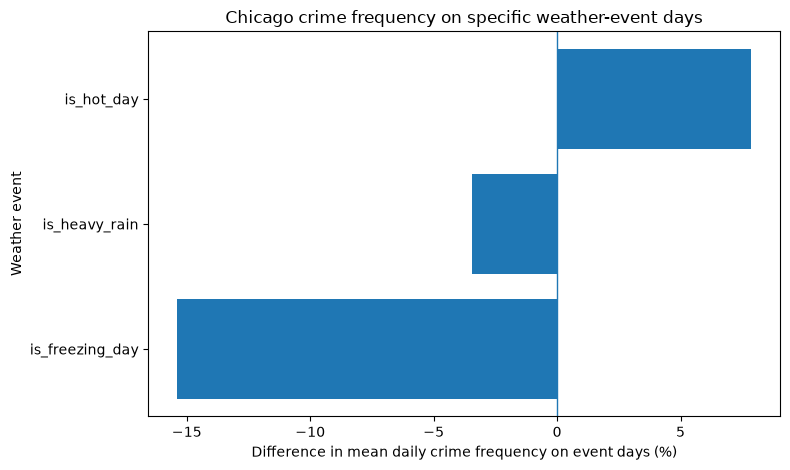

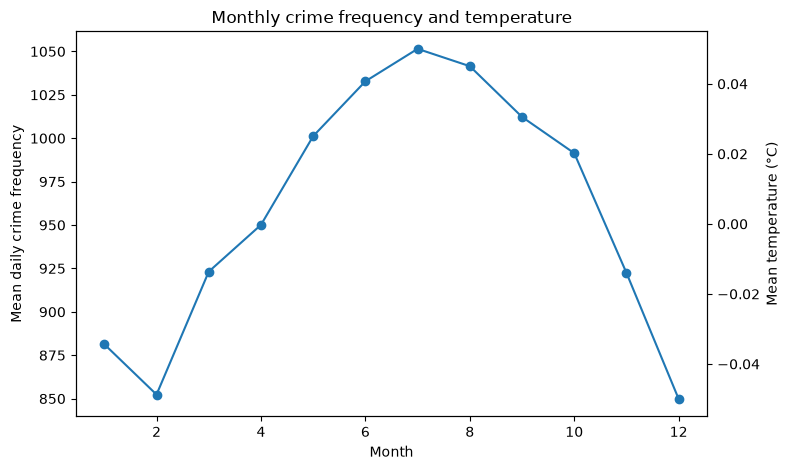

Task 2 complete.


In [6]:
# Daily crime frequency remains distributed until the final small plotting tables.
daily_counts = spark.sql("""
    SELECT crime_date, COUNT(*) AS n_crimes
    FROM crime
    WHERE crime_date IS NOT NULL
    GROUP BY crime_date
""")

weather_joined = (
    daily_counts
    .join(F.broadcast(weather), daily_counts.crime_date == weather.weather_date, "inner")
    .drop("weather_date")
    .cache()
)
print("Joined crime-weather days:", weather_joined.count())

# Continuous association computed in Spark.
corr_temp = weather_joined.stat.corr("n_crimes", "temp_avg_c")
print(f"Pearson correlation: daily crime frequency vs mean temperature = {corr_temp:.3f}")

# Event-vs-non-event effect summaries.
events = ["is_hot_day", "is_freezing_day", "is_heavy_rain", "is_snow_day"]
rows = []
for event in events:
    summary = (weather_joined.groupBy(event)
               .agg(F.count("*").alias("days"), F.avg("n_crimes").alias("mean_crimes"))
               .collect())
    d = {bool(r[event]): {"days": r["days"], "mean_crimes": r["mean_crimes"]} for r in summary}
    if True in d and False in d:
        pct_diff = 100.0 * (d[True]["mean_crimes"] / d[False]["mean_crimes"] - 1.0)
        rows.append((event, d[True]["days"], d[True]["mean_crimes"], d[False]["mean_crimes"], pct_diff))

event_summary = spark.createDataFrame(rows, ["event", "event_days", "mean_crimes_event", "mean_crimes_non_event", "pct_difference"])
event_summary.show(truncate=False)
event_pd = event_summary.toPandas()
event_pd.to_csv(os.path.join(REPORT_DIR, "task2_weather_event_summary.csv"), index=False)

# Visualisation 1: event-day difference in crime frequency.
plot_pd = event_pd.sort_values("pct_difference")
plt.figure(figsize=(8, 4.8))
plt.barh(plot_pd["event"], plot_pd["pct_difference"])
plt.axvline(0, linewidth=1)
plt.xlabel("Difference in mean daily crime frequency on event days (%)")
plt.ylabel("Weather event")
plt.title("Chicago crime frequency on specific weather-event days")
plt.tight_layout()
plt.show()

# Visualisation 2: temperature and crime frequency by month (descriptive seasonality).
monthly_weather = (weather_joined
    .withColumn("month", F.month("crime_date"))
    .groupBy("month")
    .agg(F.avg("n_crimes").alias("mean_crimes"), F.avg("temp_avg_c").alias("mean_temp_c"))
    .orderBy("month"))
monthly_pd = monthly_weather.toPandas()
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(monthly_pd["month"], monthly_pd["mean_crimes"], marker="o")
ax1.set_xlabel("Month")
ax1.set_ylabel("Mean daily crime frequency")
ax2 = ax1.twinx()
ax2.plot(monthly_pd["month"], monthly_pd["mean_temp_c"], marker="s")
ax2.set_ylabel("Mean temperature (°C)")
plt.title("Monthly crime frequency and temperature")
fig.tight_layout()
plt.show()

# Save a compact distributed result for reproducibility.
(weather_joined.select("crime_date", "n_crimes", "temp_avg_c", "temp_max_c", "precip_mm", "snow_mm", *events)
 .write.mode("overwrite").parquet(PROCESSED + "/crime_weather_daily"))

print("Task 2 complete.")
spark.stop()
